# Exercício 2 — Probabilidade de sobrevivência de um passageiro do Titanic (Multilayer Perceptron MLP)


## Contexto do problema
O desastre do Titanic é um dos acidentes marítimos mais conhecidos da história.Alguns passageiro conseguiram sobreviver com um elemento de acaso envolvido, mas há evidências que indicam que determinados grupos de passageiros tiveram mais chance de sobreviver que outros.

O objetivo nesse exercício é um problema de classificação binária. Iremos treinar um Multilayer Perceptron (MLP) capaz de  predizer a sobrevivência de um passageiro (0 = Não sobreviveu, 1 = Sobreviveu) baseado no dataset sobre dados demográficos e socioeconômicos sobre os passageiros do Titanic.

Nossa Questão central:
### *Qual tipo de passageiro tem a maior probabilidade de sobreviver?*

## Loading do Dataset e Import de bibliotecas

In [1]:
# (SHAP)
!pip install -q shap

In [27]:
!pip install kaggle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


SEED = 3
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
#Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
print("\nData Types:\n", df.dtypes)
display(df.head())

Dataset Shape: (891, 12)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Análise dos Dados

### Leganda das Colunas
| Coluna          | Significado                                                                                                                       |
| --------------- | --------------------------------------------------------------------------------------------------------------------------------- |
| **PassengerId** | Identificador único de cada passageiro no dataset.                                                                                |
| **Survived**    | Indica se o passageiro sobreviveu ao desastre (0 = Não, 1 = Sim).                                                                 |
| **Pclass**      | Classe do passageiro no navio, representando nível socioeconômico (1 = Primeira classe, 2 = Segunda classe, 3 = Terceira classe). |
| **Age**         | Idade do passageiro em anos.                                                                                                      |
| **SibSp**       | Número de irmãos ou cônjuges do passageiro que estavam a bordo.                                                                   |
| **Parch**       | Número de pais ou filhos do passageiro que estavam a bordo.                                                                       |
| **Fare**        | Valor pago pela passagem do navio.                                                                                                |
| **Name**        | Nome completo do passageiro.                                                                                                      |
| **Sex**         | Sexo do passageiro.                                                                                                               |
| **Ticket**      | Número do ticket/passagem do passageiro.                                                                                          |
| **Cabin**       | Número da cabine onde o passageiro estava acomodado.                                                                              |
| **Embarked**    | Porto onde o passageiro embarcou no Titanic (C = Cherbourg, Q = Queenstown, S = Southampton).                                     |


### Describe (Análise Estatísica)

In [4]:
print("--- Describe ---")
display(df.describe().T)

print("\n--- Sumário ---")
display(df.describe(include=['object']).T)

--- Describe ---


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



--- Sumário ---


,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,1601,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


A média da variável Survived é 0.3838, cerca de 38,4% dos passageiros sobreviveram

As idades variam de 0,42 anos (bebês) até 80 anos, com média de aproximadamente 29,7 anos.

Preço dos tickets é uma variável bem assimétrica, mediana é 14,45, mas o valor máximo chega a 512,33. Indicando que talvez uma normalização seja necessária para melhor treinamento do nosso MLP.


### Dados faltantes

,Faltantes %
Cabin,77.104377
Age,19.865320
Embarked,0.224467


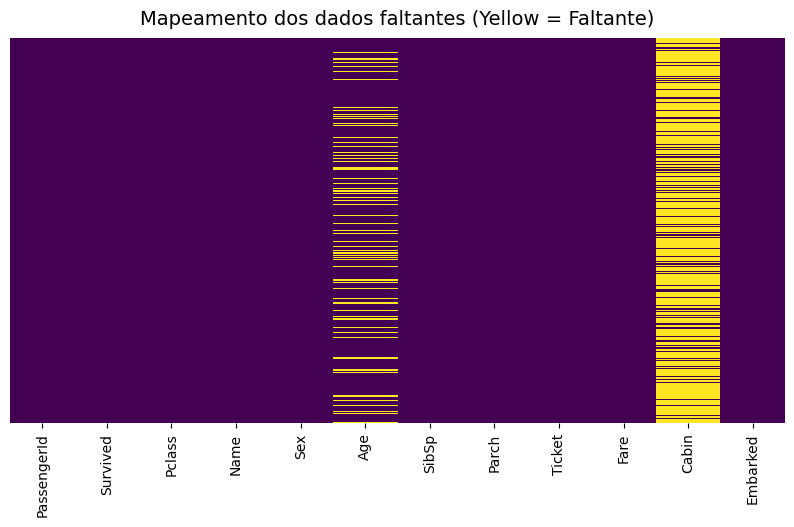

In [5]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes %': missing_pct})
display(missing_df[missing_df['Faltantes %'] > 0].sort_values(by='Faltantes %', ascending=False))

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapeamento dos dados faltantes (Amarelo = Faltante)', fontsize=14, pad=10)
plt.show()

### Balanceamento das Classes

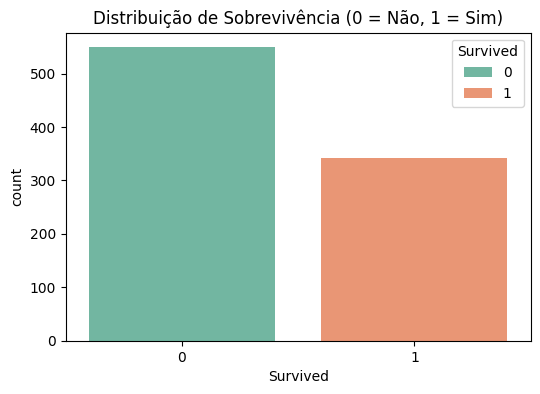

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, hue='Survived', palette='Set2')
plt.title('Distribuição de Sobrevivência (0 = Não, 1 = Sim)')
plt.show()

### Sobrevivência vs Sexo vs Classe da cabine no Navio

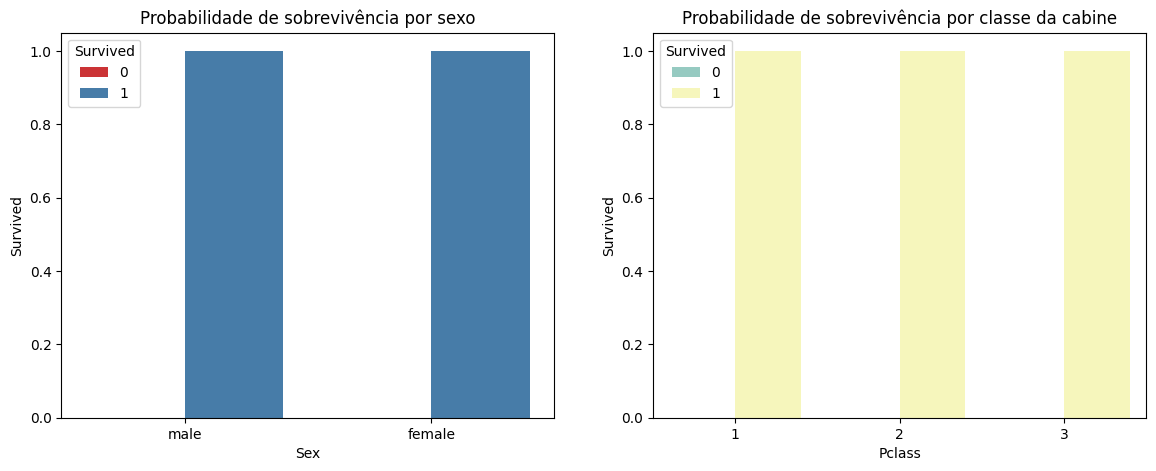

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0],hue='Survived', palette='Set1')
axes[0].set_title('Probabilidade de sobrevivência por sexo')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], hue='Survived', palette='Set3')
axes[1].set_title('Probabilidade de sobrevivência por classe da cabine')
plt.show()

### Correlações e Relação Multicolinear

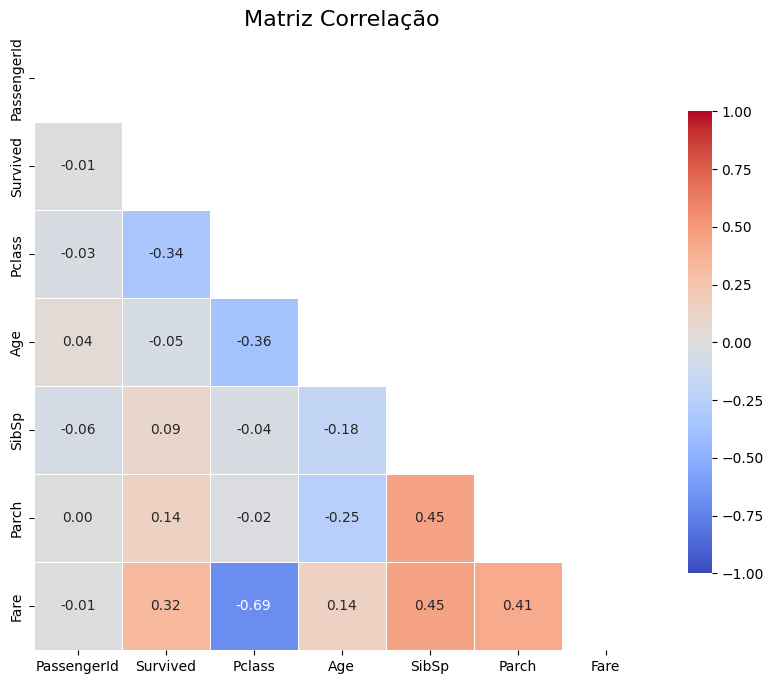

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .75})
plt.title('Matriz Correlação', fontsize=16)
plt.show()

## Limpeza de Dados

### Imputação dos valores faltantes de Idade a partir do Título de tratamento

In [9]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print("Título de Tratamento:")
print(df['Title'].value_counts())
print("\n" + "="*50 + "\n")

Título de Tratamento:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64




In [10]:
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

print("Título de Tratamento cleaned:")
print(df['Title'].value_counts())
print("\n" + "="*50 + "\n")

Título de Tratamento cleaned:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64




In [11]:
missing_before = df['Age'].isnull().sum()
print(f"Idades faltantes nos dados antes do nosso método de imputação: {missing_before}")

Idades faltantes nos dados antes do nosso método de imputação: 177


In [12]:
print("\nIdade mediana mapeada para cada Título de Tratamento:")
display(df.groupby('Title')['Age'].median())


Idade mediana mapeada para cada Título de Tratamento:


,Age
Title,
Master,3.5
Miss,21.0
Mr,30.0
Mrs,35.0
Rare,48.5


In [13]:
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))

missing_after = df['Age'].isnull().sum()
print(f"\nIdades faltantes pos imputação: {missing_after}")
print("\n" + "="*50 + "\n")


Idades faltantes pos imputação: 0




### Coluna de tamanho da família a partir do número de pais/filhos e irmãos/conjugues a bordo

In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

### Dropando colunas e setando target

In [15]:
target = 'Survived'
features_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived']
X = df.drop(columns=features_to_drop)
y = df[target]

Column Transformers and OneHotEncoder

In [16]:
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

In [17]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [18]:
from sklearn import set_config
set_config(display="diagram")
display(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare',
                                  'FamilySize']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Pclass', 'Sex', 'Embarked', 'Title'])])

In [19]:
set_config(display="text")

## Divisão dos dados de treinamento/teste/validação

In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Train shapes: X={X_train_processed.shape}, y={y_train.shape}")
print(f"Val shapes: X={X_val_processed.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test_processed.shape}, y={y_test.shape}")

Train shapes: X=(623, 18), y=(623,)
Val shapes: X=(134, 18), y=(134,)
Test shapes: X=(134, 18), y=(134,)


### Arquitetura do MLP

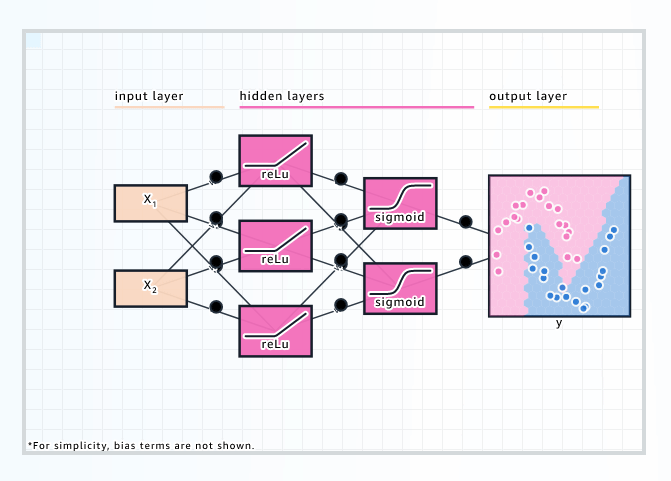

In [21]:
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

input_shape = X_train_processed.shape[1]
model = build_mlp(input_shape)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

## Treinamento do Modelo

In [22]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: weights[0], 1: weights[1]}

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 248ms/step - accuracy: 0.6162 - loss: 0.6833 - val_accuracy: 0.7985 - val_loss: 0.5595 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7262 - loss: 0.5995 - val_accuracy: 0.8657 - val_loss: 0.4934 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7598 - loss: 0.5347 - val_accuracy: 0.8657 - val_loss: 0.4407 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8136 - loss: 0.4901 - val_accuracy: 0.8731 - val_loss: 0.4035 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7949 - loss: 0.4761 - val_accuracy: 0.8731 - val_loss: 0.3799 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7797 - loss: 0.4782 - val_accuracy: 0.8731 - val_loss: 0.3686 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8058 - loss: 0.4522 

## Curva de Aprendizagem

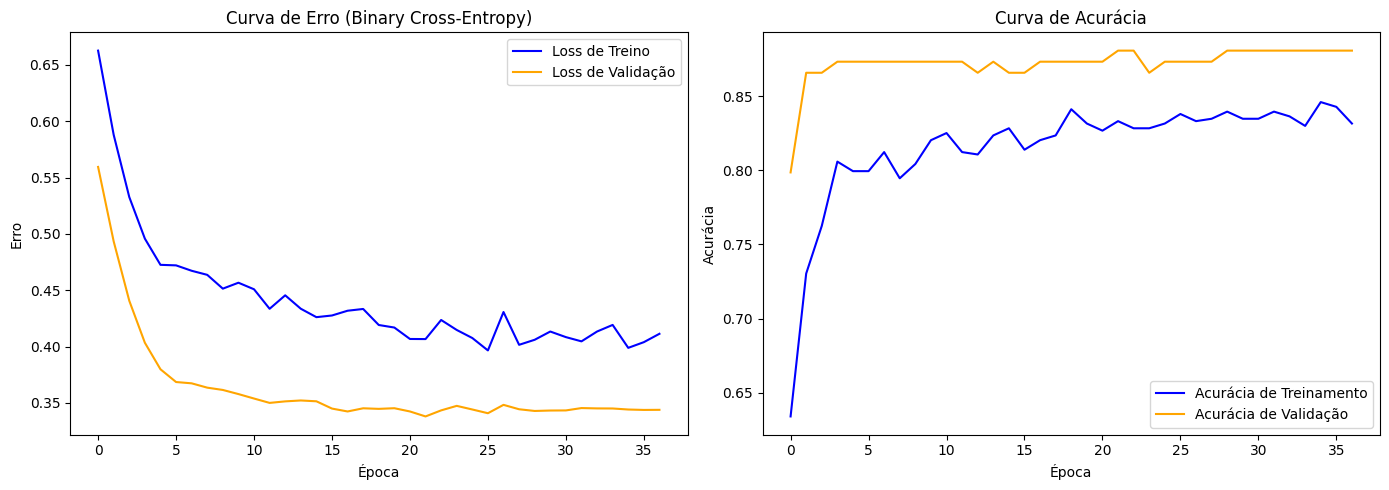

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Loss de Treino', color='blue')
axes[0].plot(history.history['val_loss'], label='Loss de Validação', color='orange')
axes[0].set_title('Curva de Erro (Binary Cross-Entropy)')
axes[0].set_ylabel('Erro')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Acurácia de Treinamento', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Acurácia de Validação', color='orange')
axes[1].set_title('Curva de Acurácia')
axes[1].set_ylabel('Acurácia')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

## Avaliando o Modelo

### Área abaixo da curva ROC

In [24]:
y_pred_probs = model.predict(X_test_processed)
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
ROC-AUC Score: 0.8361

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84        83
           1       0.76      0.69      0.72        51

    accuracy                           0.80       134
   macro avg       0.79      0.78      0.78       134
weighted avg       0.80      0.80      0.80       134



### Matriz de confusão

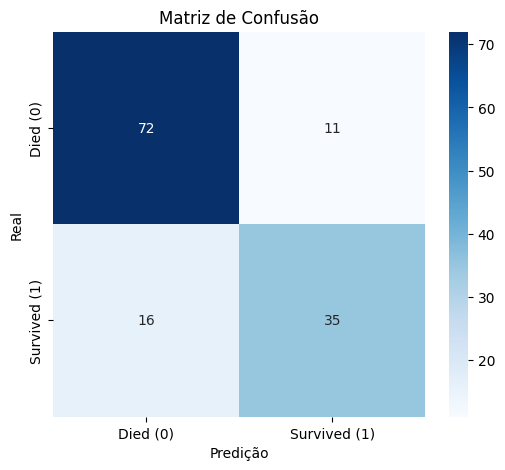

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died (0)', 'Survived (1)'],
            yticklabels=['Died (0)', 'Survived (1)'])
plt.ylabel('Real')
plt.xlabel('Predição')
plt.title('Matriz de Confusão')
plt.show()

## Explicabilidade (SHAP)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 18))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 18))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(134, 18))']
  warnings.warn(ms

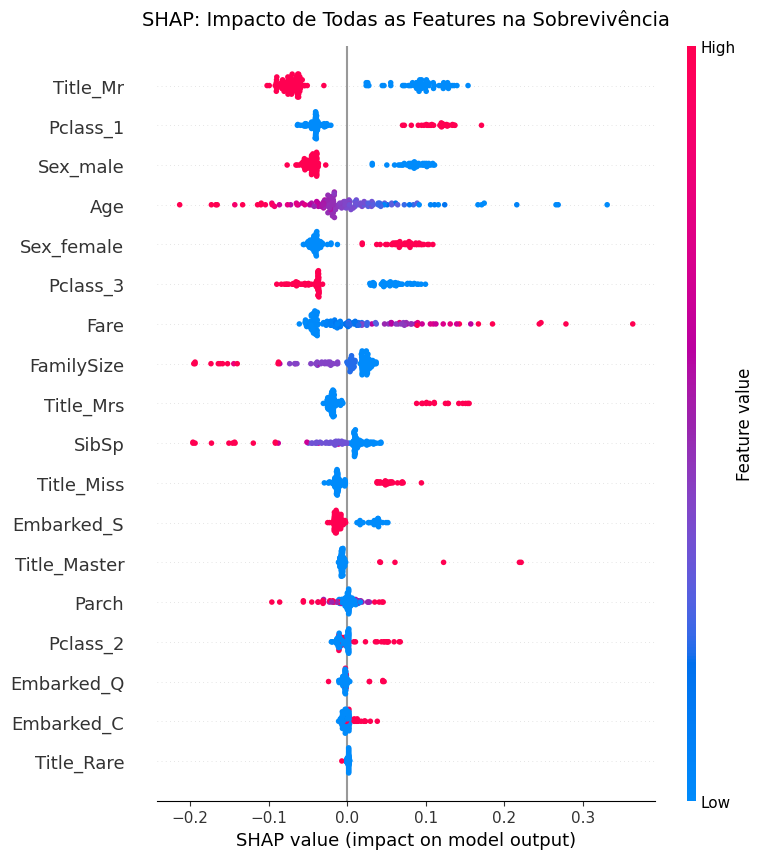

In [32]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_feature_names)

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

background = X_train_df.iloc[:100].values
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_test_df.values)

shap_values_2d = shap_values[0] if isinstance(shap_values, list) else shap_values

shap_values_2d = np.squeeze(shap_values_2d)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_2d, X_test_df, show=False)

plt.title("SHAP: Impacto de Todas as Features na Sobrevivência", fontsize=14, pad=15)
plt.tight_layout()
plt.show()